# Import Library

In [13]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
print("My numpy version is: ", np.__version__)

My numpy version is:  1.26.4


# Membaca Dataset

In [3]:
df= pd.read_csv('news.csv')

In [4]:
df

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL
...,...,...,...,...
6330,4490,State Department says it can't find emails fro...,The State Department told the Republican Natio...,REAL
6331,8062,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,FAKE
6332,8622,Anti-Trump Protesters Are Tools of the Oligarc...,Anti-Trump Protesters Are Tools of the Oligar...,FAKE
6333,4021,"In Ethiopia, Obama seeks progress on peace, se...","ADDIS ABABA, Ethiopia —President Obama convene...",REAL


## Dataframe Head

In [5]:
df.head()

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


## Dataframe Tail

In [6]:
df.tail()

,Unnamed: 0,title,text,label
6330,4490,State Department says it can't find emails fro...,The State Department told the Republican Natio...,REAL
6331,8062,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,FAKE
6332,8622,Anti-Trump Protesters Are Tools of the Oligarc...,Anti-Trump Protesters Are Tools of the Oligar...,FAKE
6333,4021,"In Ethiopia, Obama seeks progress on peace, se...","ADDIS ABABA, Ethiopia —President Obama convene...",REAL
6334,4330,Jeb Bush Is Suddenly Attacking Trump. Here's W...,Jeb Bush Is Suddenly Attacking Trump. Here's W...,REAL


## Dataframe Info

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  6335 non-null   int64 
 1   title       6335 non-null   object
 2   text        6335 non-null   object
 3   label       6335 non-null   object
dtypes: int64(1), object(3)
memory usage: 198.1+ KB


## Dataframe Shape

In [8]:
df.shape

(6335, 4)

## Dataframe Column

In [9]:
df.columns

Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')

## Cek Jumlah NaN

In [10]:
hitung_nan = df.isna().sum()
hitung_nan

Unnamed: 0    0
title         0
text          0
label         0
dtype: int64

## Cek Kolom Null

In [11]:
df_null = df.isnull().values.any()
df_null

False

# EDA & Preprocessing

In [12]:
# check the distribution of labels
df['label'].value_counts()

label
REAL    3171
FAKE    3164
Name: count, dtype: int64

## Grafik Distribusi

Text(0.5, 1.0, 'Grafik Distribusi Label')

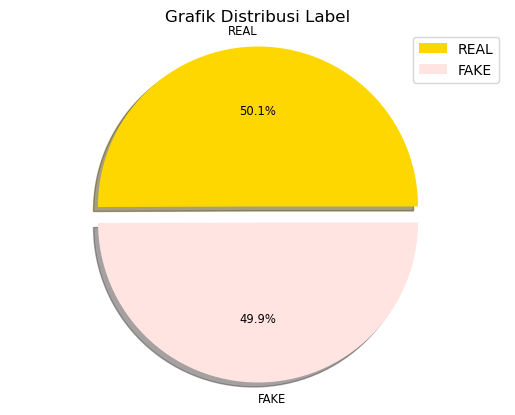

In [13]:
fig,ax = plt.subplots()
ax.pie(df['label'].value_counts(), explode={0,0.1},labels=df['label'].value_counts().index,autopct='%1.1f%%',colors=['gold','mistyrose'],shadow=True,textprops={'size': 'smaller'})
ax.axis('equal')
ax.legend()
ax.set_title('Grafik Distribusi Label')

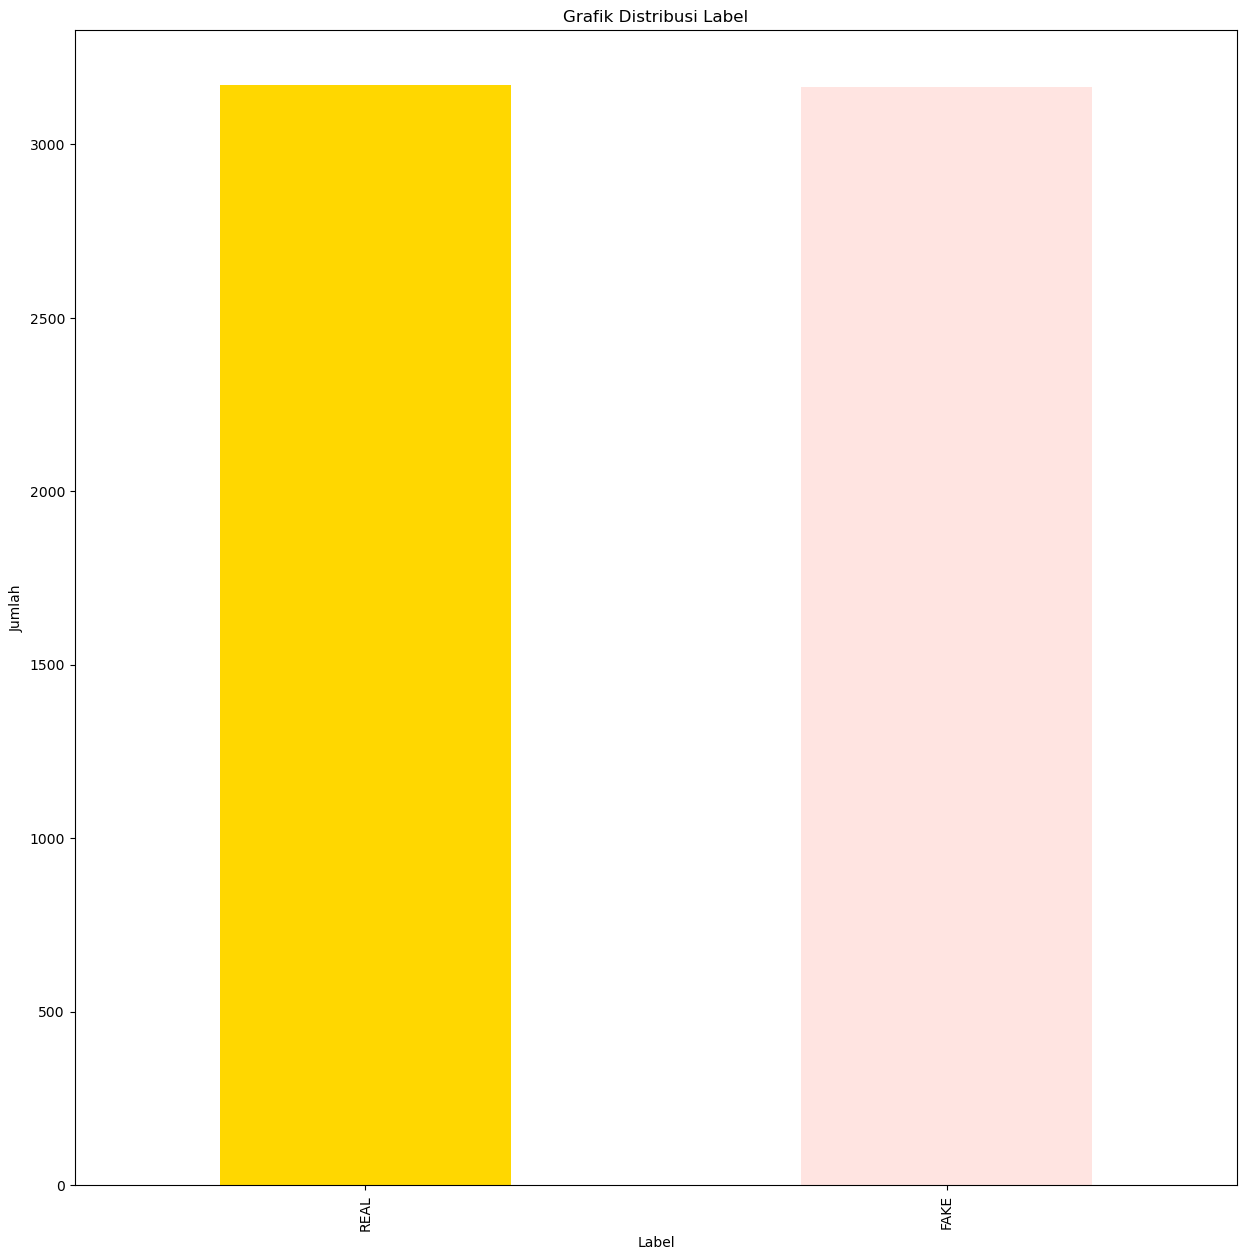

In [14]:
ax = df['label'].value_counts().plot(kind='bar',color=['gold','mistyrose'], figsize=(15,15))
ax.set_title('Grafik Distribusi Label')
ax.set_ylabel('Jumlah')
ax.set_xlabel('Label')
plt.show()

Dari uraian di atas, kita dapat melihat bahwa hampir semua label (kelas) muncul dalam jumlah yang sama dan seimbang. Sekarang kita akan menambah kolom baru untuk mengkonversi nilai kolom LABEL = FALSE, akan menjadi 0. Jika nilai kolom LABEL = TRUE, akan menjadi 1. Hal ini nanti akan menjadi bahan pengukuran kesamaan antara kata-kata. Dengan menggunakan representasi numerik dari kata-kata, kita dapat menghitung seberapa mirip dua kata berdasarkan konteks dan makna mereka. Ini berguna untuk menemukan sinonim atau kata-kata yang terkait. Library yang akan digunakan adalah Spacy.

## Kolom Baru
Nama kolom baru yang menampung hasil konversi adalah label_num

In [15]:
# Add the new column which gives a unique number to each of these labels
df['label_num'] = df['label'].map({'FAKE' : 0, 'REAL': 1})

# check the results with top 5 rows
df.head(5)

,Unnamed: 0,title,text,label,label_num
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE,0
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE,0
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL,1
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE,0
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL,1


In [39]:
!pip show spacy

Name: spacy
Version: 3.7.2
Summary: Industrial-strength Natural Language Processing (NLP) in Python
Home-page: https://spacy.io
Author: Explosion
Author-email: contact@explosion.ai
License: MIT
Location: /opt/anaconda3/lib/python3.12/site-packages
Requires: catalogue, cymem, jinja2, langcodes, murmurhash, numpy, packaging, preshed, pydantic, requests, setuptools, smart-open, spacy-legacy, spacy-loggers, srsly, thinc, tqdm, typer, wasabi, weasel
Required-by: en-core-web-lg, en-core-web-md


In [28]:
import spacy
# nlp = spacy.load("en_core_web_md")
nlp = spacy.load("en_core_web_lg")

In [29]:
df['vector'] = df['text'].apply(lambda text: nlp(text).vector)

In [30]:
df.head()

,Unnamed: 0,title,text,label,label_num,vector
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE,0,"[-1.3751823, 1.3421849, -2.3666484, 0.12908486..."
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE,0,"[-1.7449774, 0.93961924, -2.024867, 0.42536643..."
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL,1,"[-1.9426425, 1.0062195, -1.9992222, 0.20469022..."
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE,0,"[-1.9125352, -0.1481846, -1.1432766, 0.6861217..."
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL,1,"[-1.8516092, 1.3163909, -2.1726575, 1.2286776,..."


In [31]:
df

,Unnamed: 0,title,text,label,label_num,vector
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE,0,"[-1.3751823, 1.3421849, -2.3666484, 0.12908486..."
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE,0,"[-1.7449774, 0.93961924, -2.024867, 0.42536643..."
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL,1,"[-1.9426425, 1.0062195, -1.9992222, 0.20469022..."
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE,0,"[-1.9125352, -0.1481846, -1.1432766, 0.6861217..."
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL,1,"[-1.8516092, 1.3163909, -2.1726575, 1.2286776,..."
...,...,...,...,...,...,...
6330,4490,State Department says it can't find emails fro...,The State Department told the Republican Natio...,REAL,1,"[-1.556691, 0.60453945, -1.1016529, 0.16134764..."
6331,8062,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,FAKE,0,"[-2.206026, -0.12085343, -1.0834901, 0.6655213..."
6332,8622,Anti-Trump Protesters Are Tools of the Oligarc...,Anti-Trump Protesters Are Tools of the Oligar...,FAKE,0,"[-2.558132, 0.47698027, -1.8662019, 0.8344748,..."
6333,4021,"In Ethiopia, Obama seeks progress on peace, se...","ADDIS ABABA, Ethiopia —President Obama convene...",REAL,1,"[-1.8501893, 0.6893597, -1.9594386, 0.41594952..."


## Split Data

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.vector.values,
    df.label_num,
    test_size=0.2,
    random_state=2022
)

In [33]:
X_train_2d = np.stack(X_train)
X_test_2d = np.stack(X_test)

## Data Scalling

In [34]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_train_embed = scaler.fit_transform(X_train_2d)
scaled_test_embed = scaler.transform(X_test_2d)

# Model

## Naive Bayes Model

In [35]:
from sklearn.naive_bayes import MultinomialNB

clf = MultinomialNB()
clf.fit(scaled_train_embed, y_train)

MultinomialNB()

In [36]:
from sklearn.metrics import classification_report
y_pred = clf.predict(scaled_test_embed)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.69      0.76       634
           1       0.73      0.87      0.80       633

    accuracy                           0.78      1267
   macro avg       0.79      0.78      0.78      1267
weighted avg       0.79      0.78      0.78      1267



## KNN Model

In [37]:
from  sklearn.neighbors import KNeighborsClassifier

#1. creating a KNN model object
clf = KNeighborsClassifier(n_neighbors = 5, metric = 'euclidean')

#2. fit with all_train_embeddings and y_train
clf.fit(X_train_2d, y_train)

#3. get the predictions for all_test_embeddings and store it in y_pred
y_pred = clf.predict(X_test_2d)

#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.76      0.83       634
           1       0.80      0.92      0.85       633

    accuracy                           0.84      1267
   macro avg       0.85      0.84      0.84      1267
weighted avg       0.85      0.84      0.84      1267



# Confussion Matrix

Text(95.72222222222221, 0.5, 'Truth')

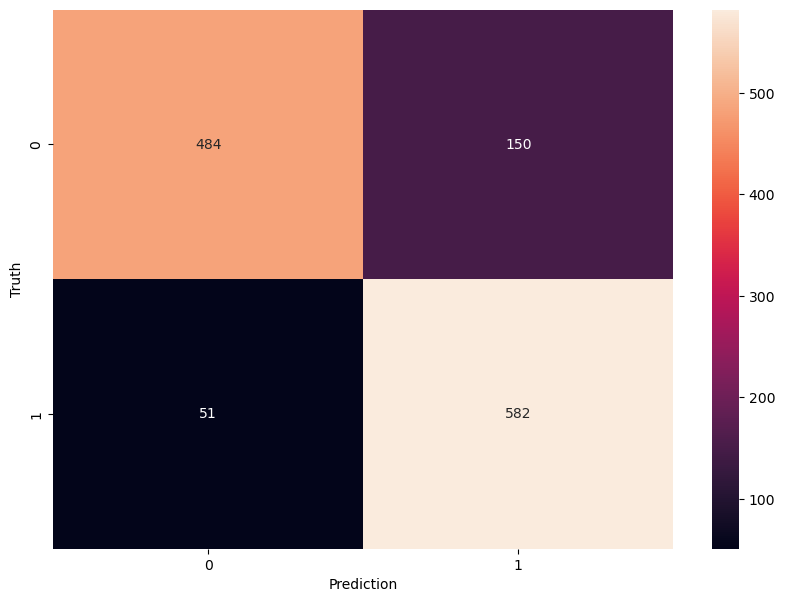

In [38]:
#finally print the confusion matrix for the best model
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

from matplotlib import pyplot as plt
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Truth')

Poin-poin Penting
Model KNN yang tidak berkinerja baik dalam teknik vektorisasi seperti Bag of words, dan TF-IDF karena ruang vektor berdimensi sangat tinggi, berkinerja sangat baik dengan vektor glove karena hanya memiliki vektor 300 dimensi dan embedding yang sangat baik (kata-kata yang mirip dan terkait memiliki embedding yang hampir serupa) untuk data teks yang diberikan.

Model MultinomialNB berkinerja cukup baik tetapi tidak masuk dalam daftar teratas karena dalam vektor 300 dimensi kami juga memiliki nilai negatif. Model Naive Bayes tidak sesuai dengan data jika ada nilai negatif. Jadi, untuk mengatasi kekurangan ini, kami telah menggunakan Min-Max scaler untuk menurunkan semua nilai antara 0 hingga 1. Dalam proses ini, akan ada kemungkinan varians dan kehilangan informasi di antara data. Namun, kami mendapatkan recall dan skor f1 yang layak.

# Opsi Kedua
Jangan lupa untuk menjalankan bagian import librarynya

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import re
import string

In [15]:
df2= pd.read_csv('news.csv')

In [16]:
# Add the new column which gives a unique number to each of these labels
df2['label_num'] = df2['label'].map({'FAKE' : 0, 'REAL': 1})

# check the results with top 5 rows
df2.head(5)

,Unnamed: 0,title,text,label,label_num
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE,0
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE,0
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL,1
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE,0
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL,1


## Creating a function to process the texts

In [17]:
def wordopt(text):
    text = text.lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub("\\W"," ",text) 
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)    
    return text

<>:3: SyntaxWarning: invalid escape sequence '\['
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\w'
<>:3: SyntaxWarning: invalid escape sequence '\['
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\w'
/var/folders/0t/4f36_5g10_z18x85bxd4z_8w0000gn/T/ipykernel_2690/3432647204.py:3: SyntaxWarning: invalid escape sequence '\['
  text = re.sub('\[.*?\]', '', text)
/var/folders/0t/4f36_5g10_z18x85bxd4z_8w0000gn/T/ipykernel_2690/3432647204.py:5: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub('https?://\S+|www\.\S+', '', text)
/var/folders/0t/4f36_5g10_z18x85bxd4z_8w0000gn/T/ipykernel_2690/3432647204.py:9: SyntaxWarning: invalid escape sequence '\w'
  text = re.sub('\w*\d\w*', '', text)


In [19]:
df2["text"] = df2["text"].apply(wordopt)

## Defining dependent and independent variables

In [21]:
x = df2["text"]
y = df2["label_num"]

## Splitting Training and Testing

In [22]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25)

## Convert text to vectors

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorization = TfidfVectorizer()
xv_train = vectorization.fit_transform(x_train)
xv_test = vectorization.transform(x_test)

## Logistic Regression

In [24]:
from sklearn.linear_model import LogisticRegression

LR = LogisticRegression()
LR.fit(xv_train,y_train)

LogisticRegression()

In [25]:
pred_lr=LR.predict(xv_test)

In [26]:
LR.score(xv_test, y_test)

0.9109848484848485

In [27]:
print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91       804
           1       0.92      0.90      0.91       780

    accuracy                           0.91      1584
   macro avg       0.91      0.91      0.91      1584
weighted avg       0.91      0.91      0.91      1584



## Decision Tree Classification

In [29]:
from sklearn.tree import DecisionTreeClassifier

DT = DecisionTreeClassifier()
DT.fit(xv_train, y_train)

DecisionTreeClassifier()

In [30]:
pred_dt = DT.predict(xv_test)

In [31]:
DT.score(xv_test, y_test)

0.7967171717171717

In [32]:
print(classification_report(y_test, pred_dt))

              precision    recall  f1-score   support

           0       0.79      0.81      0.80       804
           1       0.80      0.78      0.79       780

    accuracy                           0.80      1584
   macro avg       0.80      0.80      0.80      1584
weighted avg       0.80      0.80      0.80      1584



## Gradient Boosting Classifier

In [33]:
from sklearn.ensemble import GradientBoostingClassifier

GBC = GradientBoostingClassifier(random_state=0)
GBC.fit(xv_train, y_train)

GradientBoostingClassifier(random_state=0)

In [34]:
pred_gbc = GBC.predict(xv_test)

In [35]:
GBC.score(xv_test, y_test)

0.8964646464646465

In [36]:
print(classification_report(y_test, pred_gbc))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90       804
           1       0.91      0.88      0.89       780

    accuracy                           0.90      1584
   macro avg       0.90      0.90      0.90      1584
weighted avg       0.90      0.90      0.90      1584



## Random Forest Classifier

In [37]:
from sklearn.ensemble import RandomForestClassifier

RFC = RandomForestClassifier(random_state=0)
RFC.fit(xv_train, y_train)

RandomForestClassifier(random_state=0)

In [38]:
pred_rfc = RFC.predict(xv_test)

In [39]:
RFC.score(xv_test, y_test)

0.8926767676767676

In [40]:
print(classification_report(y_test, pred_rfc))

              precision    recall  f1-score   support

           0       0.89      0.90      0.89       804
           1       0.90      0.88      0.89       780

    accuracy                           0.89      1584
   macro avg       0.89      0.89      0.89      1584
weighted avg       0.89      0.89      0.89      1584



## Model Testing

In [41]:
def output_lable(n):
    if n == 0:
        return "Fake News"
    elif n == 1:
        return "Not A Fake News"
    
def manual_testing(news):
    testing_news = {"text":[news]}
    new_def_test = pd.DataFrame(testing_news)
    new_def_test["text"] = new_def_test["text"].apply(wordopt) 
    new_x_test = new_def_test["text"]
    new_xv_test = vectorization.transform(new_x_test)
    pred_LR = LR.predict(new_xv_test)
    pred_DT = DT.predict(new_xv_test)
    pred_GBC = GBC.predict(new_xv_test)
    pred_RFC = RFC.predict(new_xv_test)

    return print("\n\nLR Prediction: {} \nDT Prediction: {} \nGBC Prediction: {} \nRFC Prediction: {}".format(output_lable(pred_LR[0]),                                                                                                       output_lable(pred_DT[0]), 
                                                                                                              output_lable(pred_GBC[0]), 
                                                                                                              output_lable(pred_RFC[0])))

In [45]:
news = str(input())
manual_testing(news)

 Google Pinterest Digg Linkedin Reddit Stumbleupon Print Delicious Pocket Tumblr  There are two fundamental truths in this world: Paul Ryan desperately wants to be president. And Paul Ryan will never be president. Today proved it.  In a particularly staggering example of political cowardice, Paul Ryan re-re-re-reversed course and announced that he was back on the Trump Train after all. This was an aboutface from where he was a few weeks ago. He had previously declared he would not be supporting or defending Trump after a tape was made public in which Trump bragged about assaulting women. Suddenly, Ryan was appearing at a pro-Trump rally and boldly declaring that he already sent in his vote to make him President of the United States. It was a surreal moment. The figurehead of the Republican Party dosed himself in gasoline, got up on a stage on a chilly afternoon in Wisconsin, and lit a match. . @SpeakerRyan says he voted for @realDonaldTrump : “Republicans, it is time to come home” http



LR Prediction: Fake News 
DT Prediction: Fake News 
GBC Prediction: Fake News 
RFC Prediction: Fake News


In [46]:
news = str(input())
manual_testing(news)

 U.S. Secretary of State John F. Kerry said Monday that he will stop in Paris later this week, amid criticism that no top American officials attended Sunday’s unity march against terrorism.  Kerry said he expects to arrive in Paris Thursday evening, as he heads home after a week abroad. He said he will fly to France at the conclusion of a series of meetings scheduled for Thursday in Sofia, Bulgaria. He plans to meet the next day with Foreign Minister Laurent Fabius and President Francois Hollande, then return to Washington.  The visit by Kerry, who has family and childhood ties to the country and speaks fluent French, could address some of the criticism that the United States snubbed France in its darkest hour in many years.  The French press on Monday was filled with questions about why neither President Obama nor Kerry attended Sunday’s march, as about 40 leaders of other nations did. Obama was said to have stayed away because his own security needs can be taxing on a country, and Ke



LR Prediction: Not A Fake News 
DT Prediction: Not A Fake News 
GBC Prediction: Not A Fake News 
RFC Prediction: Not A Fake News
